In [1]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import polars as pl
import numpy as np
import optuna

In [2]:
from pathlib import Path
path = Path.cwd()
if not Path(path, "data").exists(): path = path.parent

In [3]:
df_train = pl.read_parquet(path / "data" / "train_fare.parquet")
df_val = pl.read_parquet(path / "data" / "val_fare.parquet")
df_test = pl.read_parquet(path / "data" / "test_fare.parquet")

In [22]:
df_train.collect_schema()

Schema([('PULocationID', Int16),
        ('DOLocationID', Int16),
        ('fare_amount', Int16),
        ('payment_type', Int8),
        ('VendorID', Int8),
        ('trip_distance', Int32),
        ('temperature_2m', Float64),
        ('precipitation', Float64),
        ('rain', Float64),
        ('snowfall', Float64),
        ('month', Int8),
        ('dayofyear', Int16),
        ('weekday', Int8),
        ('hour', Float64)])

In [4]:
categorical_cols = ["payment_type", "VendorID", "weekday", "month", 'PULocationID', 'DOLocationID']
input_cols = [col for col in df_train.columns if col not in ['fare_amount']]

x_train, y_train = df_train.select(input_cols), df_train.select("fare_amount").to_numpy()
x_test, y_test = df_test.select(input_cols), df_test.select("fare_amount").to_numpy()
x_val, y_val = df_val.select(input_cols), df_val.select("fare_amount").to_numpy()

## Prueba con rmse

In [31]:
train_data = lgb.Dataset(
    data=x_train, 
    label=y_train, 
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    free_raw_data=False
)

val_data = lgb.Dataset(
    data=x_val, 
    label=y_val, 
    reference=train_data,
    feature_name=input_cols
)

lgbm_params = {
    'objective': 'tweedie',
    'boosting': 'gbdt',
    'max_bin': 255,
    'metric': 'rmse',
    'verbose': -1,
    'tweedie_variance_power': 1.5736005740734198,
    'learning_rate': 0.10469439266335008,
    'num_leaves': 268,
    'max_depth': 12,
    'min_data_in_leaf': 702,
    'feature_fraction': 0.6035669550945819,
    'bagging_fraction': 0.979833460020387,
    'bagging_freq': 4,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=['Entrenamiento', 'Validacion'],
    
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's rmse: 695.561	Validacion's rmse: 840.164
[200]	Entrenamiento's rmse: 678.967	Validacion's rmse: 832.13
[300]	Entrenamiento's rmse: 671.057	Validacion's rmse: 830.44
[400]	Entrenamiento's rmse: 666.154	Validacion's rmse: 829.502
[500]	Entrenamiento's rmse: 662.817	Validacion's rmse: 828.76
[600]	Entrenamiento's rmse: 660.084	Validacion's rmse: 828.078
[700]	Entrenamiento's rmse: 657.484	Validacion's rmse: 827.731
Early stopping, best iteration is:
[735]	Entrenamiento's rmse: 656.67	Validacion's rmse: 827.549


In [28]:
model_lgb.save_model(path / "data" / "lgbm_rmse827.549_fin_fare.txt")

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

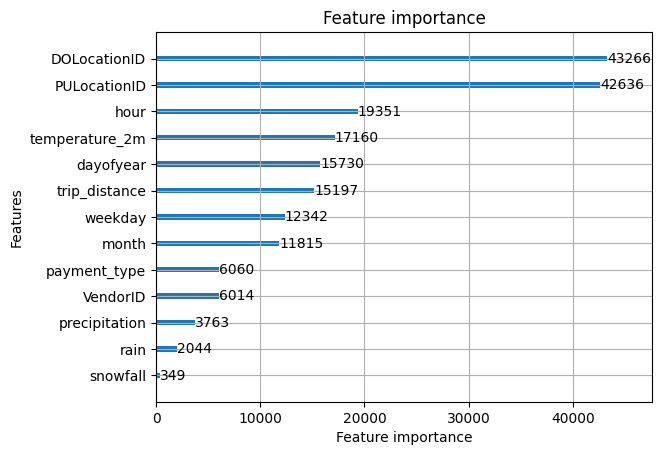

In [29]:
lgb.plot_importance(model_lgb)

Vemos que los datos meteorológicos aportan valor.

In [7]:
def evaluar_modelo(y_true, y_pred, nombre_set="Test"):
    """
    Evalúa predicciones de regresión y devuelve un diccionario con las métricas.
    Soporta entradas como Series de Polars, listas o arrays de NumPy.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    media_real = np.mean(y_true)
    media_pred = np.mean(y_pred)
    
    print(f"\n--- REPORTE DE RENDIMIENTO: {nombre_set} ---")
    print(f"MAE  (Error Absoluto Medio):       {mae:.4f}")
    print(f"RMSE (Raíz del Error Cuadrático):  {rmse:.4f}")
    print(f"R²   (Coef. de Determinación):     {r2:.4f}")
    print("-" * 45)
    print(f"Propina media real del set:        {media_real:.4f}")
    print(f"Propina media predicha:            {media_pred:.4f}")
    print("-" * 45)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Media_Real": media_real,
        "Media_Pred": media_pred
    }

In [ ]:
predicciones = model_lgb.predict(x_test)
metricas_finales = evaluar_modelo(y_test, predicciones, nombre_set="Test (Nov-Dic 2025) num optuna")

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) num optuna ---
MAE  (Error Absoluto Medio):       515.0307
RMSE (Raíz del Error Cuadrático):  883.0348
R²   (Coef. de Determinación):     0.8195
---------------------------------------------
Propina media real del set:        2577.7257
Propina media predicha:            2388.4749
---------------------------------------------


## Entrenamiento con huber

In [12]:
train_data = lgb.Dataset(
    data=x_train, 
    label=y_train, 
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    free_raw_data=False
)

val_data = lgb.Dataset(
    data=x_val, 
    label=y_val, 
    reference=train_data,
    feature_name=input_cols
)

lgbm_params = {
    'objective': 'tweedie',
    'boosting': 'gbdt',
    'max_bin': 255,
    'metric': 'huber',
    'verbose': -1,
    'tweedie_variance_power': 1.5736005740734198,
    'learning_rate': 0.10469439266335008,
    'num_leaves': 268,
    'max_depth': 12,
    'min_data_in_leaf': 702,
    'feature_fraction': 0.6035669550945819,
    'bagging_fraction': 0.979833460020387,
    'bagging_freq': 4,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=3000,
    valid_sets=[train_data, val_data],
    valid_names=['Entrenamiento', 'Validacion'],
    
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, first_metric_only=False, verbose=True),
        lgb.log_evaluation(period=50)
    ]
) # huber

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


Training until validation scores don't improve for 50 rounds
[50]	Entrenamiento's huber: 384.747	Validacion's huber: 450.048
[100]	Entrenamiento's huber: 367.651	Validacion's huber: 433.14
[150]	Entrenamiento's huber: 361.261	Validacion's huber: 428.921
[200]	Entrenamiento's huber: 357.385	Validacion's huber: 427.722
[250]	Entrenamiento's huber: 354.676	Validacion's huber: 426.918
[300]	Entrenamiento's huber: 352.609	Validacion's huber: 426.317
[350]	Entrenamiento's huber: 350.944	Validacion's huber: 425.707
[400]	Entrenamiento's huber: 349.726	Validacion's huber: 425.349
[450]	Entrenamiento's huber: 348.615	Validacion's huber: 424.962
[500]	Entrenamiento's huber: 347.79	Validacion's huber: 424.865
[550]	Entrenamiento's huber: 346.976	Validacion's huber: 424.577
[600]	Entrenamiento's huber: 346.212	Validacion's huber: 424.422
[650]	Entrenamiento's huber: 345.421	Validacion's huber: 424.275
[700]	Entrenamiento's huber: 344.721	Validacion's huber: 424.219
Early stopping, best iteration i

In [13]:
model_lgb.save_model(path / "data" / "lgbm_huber424.114_fare.txt")

In [17]:
predicciones = model_lgb.predict(x_test)
metricas_finales = evaluar_modelo(y_test, predicciones, nombre_set="Test (Nov-Dic 2025) num optuna")

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) num optuna ---
MAE  (Error Absoluto Medio):       515.1398
RMSE (Raíz del Error Cuadrático):  883.2986
R²   (Coef. de Determinación):     0.8194
---------------------------------------------
Propina media real del set:        2577.7257
Propina media predicha:            2388.2702
---------------------------------------------


Prácticamente el mismo resultado.

## Modelo final

Nos quedamos con rmse ya que es algo mejor.

In [14]:
lgbm_final = lgb.Booster(model_file=path / "data" / "lgbm_huber424.114_fare.txt")

In [16]:
predicciones = lgbm_final.predict(x_test)
metricas_finales = evaluar_modelo(y_test, predicciones, nombre_set="Final Model Fare")

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Final Model Fare ---
MAE  (Error Absoluto Medio):       515.1398
RMSE (Raíz del Error Cuadrático):  883.2986
R²   (Coef. de Determinación):     0.8194
---------------------------------------------
Propina media real del set:        2577.7257
Propina media predicha:            2388.2702
---------------------------------------------


In [8]:
predicciones = lgbm_final.predict(x_test)
metricas_finales = evaluar_modelo(y_test, predicciones, nombre_set="Final Model Fare")


--- REPORTE DE RENDIMIENTO: Final Model Fare ---
MAE  (Error Absoluto Medio):       515.0307
RMSE (Raíz del Error Cuadrático):  883.0348
R²   (Coef. de Determinación):     0.8195
---------------------------------------------
Propina media real del set:        2577.7257
Propina media predicha:            2388.4749
---------------------------------------------
